In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Fix randomness so that every time you run the code,
# you get the same random numbers → results are reproducible
np.random.seed(0)

# Generate input feature X
# np.random.rand(100, 1) → 100 random values are [0,1]
# Multiply by 2 → now values are [0,2]
# Shape: (100 samples, 1 feature)
X = 2 * np.random.rand(100, 1)


# Generate output y using a linear relation:
# y = 4 + 3*X + noise
# 4 → intercept (bias)
# 3 → slope (weight of X)
# np.random.randn(100,1) → Gaussian noise (mean=0, std=1)
# Noise makes data realistic (not perfectly linear)
y = 4 + 3 * X + np.random.randn(100, 1)


# Train-Test split (80% training, 20% testing)
# Total samples = 100 → 80 for training, 20 for testing
split = int(0.8 * len(X))

# First 80 samples → training data
X_train = X[:split]
y_train = y[:split]

# Remaining 20 samples → testing data
X_test = X[split:]
y_test = y[split:]

print("First 5 Input examples : ",X_train[:5])
print("First 5 O/P : ",y_train[:5])


First 5 Input examples :  [[1.09762701]
 [1.43037873]
 [1.20552675]
 [1.08976637]
 [0.8473096 ]]
First 5 O/P :  [[6.12773118]
 [9.19196269]
 [8.0822427 ]
 [5.73305541]
 [8.03018099]]


In [6]:
# Split training data into 5 parts (folds)
# → each part will act once as validation
# → remaining data used for training

# Take turns:
#- pick one part as validation
# - use rest as training

# “Every part of data gets a chance to be validation”

def create_folds(X, y, k=5):
    # Total number of samples
    n = len(X)

    # Create array of indices: [0, 1, 2, ..., n-1]
    indices = np.arange(n)

    # Shuffle indices randomly to avoid ordered bias
    np.random.shuffle(indices)

    # Size of each fold
    # Example: n=80, k=5 → fold_size=16
    fold_size = n // k

    # List to store (train_idx, val_idx) pairs
    folds = []

    # Loop over each fold
    for i in range(k):

        # Define start and end of validation indices
        start = i * fold_size
        end = (i + 1) * fold_size

        # Validation indices for current fold
        val_idx = indices[start:end]

        # Training indices = all remaining indices
        train_idx = np.concatenate ( (indices[:start], indices[end:]) )

        # Store this split as a tuple
        folds.append((train_idx, val_idx))

    # Return list of all folds
    return folds

In [7]:
class LinearRegressionScratch:
    def __init__(self, eta=0.01, epochs=1000, lam=0, reg_type=None):
        # Learning rate (how big each step is)
        self.eta = eta
        
        # Number of iterations for gradient descent
        self.epochs = epochs
        
        # Regularization strength (λ)
        self.lam = lam
        
        # Type of regularization: 'ridge' or 'lasso'
        self.reg_type = reg_type
        
        # Store loss values for plotting
        self.train_loss = []
        
        # Parameters (θ) → will be learned
        self.theta = None
        
        # Store θ at each step (optional analysis)
        self.theta_history = []

    def compute_loss(self, X, y):
        # n = number of samples
        n = X.shape[1]

        # Predictions: h = X^T * θ
        # shape: (n, 1)
        h = np.dot(X.T, self.theta)

        # Error term: (prediction - actual)
        term = h - y.reshape(n, 1)

        # MSE Loss = (1/n) * (error^2)
        loss = (1 / n) * np.dot(term.T, term)

        # 🔥 Add regularization penalty

        # Ridge: λ * Σ(θ^2)
        if self.reg_type == 'ridge':
            loss += self.lam * np.sum(self.theta**2)

        # Lasso: λ * Σ(|θ|)
        elif self.reg_type == 'lasso':
            loss += self.lam * np.sum(np.abs(self.theta))

        # Convert from array to scalar
        return loss.item()

    def fit(self, X, y):
        # Transpose so shape becomes (features, samples) -> m*n
        X = X.T
        m, n = X.shape   # m = features, n = samples

        # Add bias row (all 1s)
        # Now X shape: (m+1, n) 
        X = np.vstack( (np.ones((1, n)), X) )

        # Ensure y is column vector (n, 1)
        y = y.reshape(n, 1)

        # Initialize θ = zeros → shape (m+1, 1)
        self.theta = np.zeros((m + 1, 1))

        # Gradient Descent loop
        for _ in range(self.epochs):
            # Predictions
            h = np.dot(X.T, self.theta)   # (n, 1)

            # Gradient of MSE loss
            # (m+1, 1)
            gradient = (2 / n) * np.dot(X, (h - y))

            # 🔥 Add regularization gradient
            # Ridge derivative: 2λθ
            if self.reg_type == 'ridge':
                gradient += 2 * self.lam * self.theta

            # Lasso derivative: λ * sign(θ)
            elif self.reg_type == 'lasso':
                gradient += self.lam * np.sign(self.theta)

            # Update rule: θ = θ - η * gradient
            self.theta -= self.eta * gradient

            # Store loss for analysis
            self.train_loss.append(self.compute_loss(X, y))

            # Store θ history (optional)
            self.theta_history.append(self.theta.copy())

    def predict(self, X):
        # X shape: (samples, features)
        n, m = X.shape

        # Transpose → (features, samples)
        X = X.T

        # Add bias row
        X = np.vstack((np.ones((1, X.shape[1])), X))

        # Return predictions → flatten to 1D
        return np.dot(X.T, self.theta).flatten()

In [8]:
# For each λ:
    # Train model 5 times (using folds)
    # Compute validation error each time
    # Take average → final score for that λ

# “For each λ, we perform 5-fold cross-validation, compute validation error for each fold, 
# and take the average to select the optimal λ.”

# Different λ values to test
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

# Number of folds
k = 5

# Create 5 splits of training data
folds = create_folds(X_train, y_train, k)

# Store average validation error for each λ
val_errors =[]

# 🔁 Loop over each λ
for lam in lambdas :
    # Store errors from each fold
    fold_errors = []

    # 🔁 Loop over each fold
    for train_idx, val_idx in folds:
        # Split into training and validation sets
        # train_idx, val_idx - They are arrays of integers (indices)
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        # Create model with current λ
        model = LinearRegressionScratch(lam=lam, reg_type='ridge')

        # Train model
        model.fit(X_tr, y_tr)

        # Predict on validation set
        y_pred = model.predict(X_val)

        # Compute validation error (Mean Squared Error)
        error = np.mean( (y_pred - y_val.flatten())**2)

        # Store error for this fold
        fold_errors.append(error)

    # Compute average error across all folds
    avg_error = np.mean(fold_errors)

    # Store average error for this λ
    val_errors.append(avg_error)

    # Print result
    print(f"λ={lam} → Avg Validation Error={avg_error}")

λ=0.0001 → Avg Validation Error=1.0794164902732664
λ=0.001 → Avg Validation Error=1.07919860565413
λ=0.01 → Avg Validation Error=1.0788204528956802
λ=0.1 → Avg Validation Error=1.2055855239532884
λ=1 → Avg Validation Error=6.745160046232323
λ=10 → Avg Validation Error=38.04540201959942


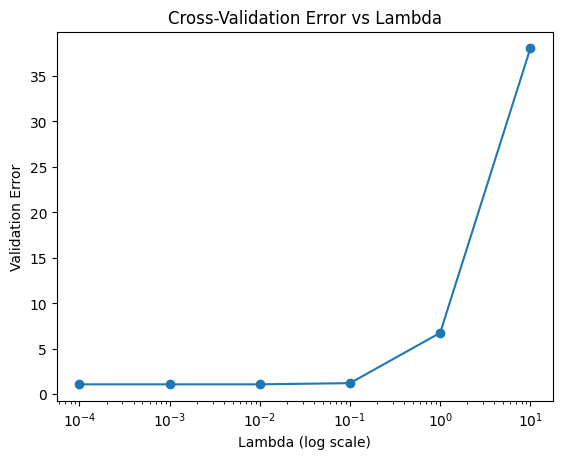

In [ ]:
plt.plot(lambdas, val_errors, marker='o')
plt.xscale('log')

plt.xlabel("Lambda (log scale)")
plt.ylabel("Validation Error")
plt.title("Cross-Validation Error vs Lambda")

plt.show()

# The validation error is lowest for small λ values, indicating a good balance between fitting and regularization. 
# As λ increases, the model underfits, causing error to rise. Log scale is used to visualize λ values spanning 
# multiple orders of magnitude.”

In [9]:
best_index = np.argmin(val_errors)
best_lambda = lambdas[best_index]
print("Best λ:", best_lambda)

Best λ: 0.01


In [10]:
final_model = LinearRegressionScratch(lam=best_lambda, reg_type='ridge')
final_model.fit(X_train, y_train)

In [11]:
y_test_pred = final_model.predict(X_test)
test_error = np.mean( (y_test_pred - y_test.flatten())**2 )
print("Test Error:", test_error)

Test Error: 0.8812999361549496


In [ ]:

# OBSERVATIONS:

# 1. Cross-validation helps in selecting the best λ by evaluating model performance on unseen validation data.

# 2. For very small λ: Model behaves like normal regression and may overfit.

# 3. For very large λ: Model becomes too simple and underfits.

# 4. The optimal λ is the one that minimizes validation error.

# 5. After selecting the best λ, retraining on full training data gives the final model.

# 6. Test error gives an unbiased estimate of model performance on new data.